In [33]:
from phidl import Device, Layer, LayerSet, Port, Path, CrossSection
from phidl.device_layout import DeviceReference
from phidl import quickplot as qp

import phidl.geometry as pg
import phidl.utilities as pu
import phidl.routing as pr
import phidl.path as pp

import numpy as np
import pickle

from dataclasses import dataclass, field, replace

from typing import Tuple, Optional, Union

import itertools
import importlib

from components import utils
importlib.reload(utils)

from components import default_layerset
importlib.reload(default_layerset)
from components import frame
importlib.reload(frame)
from components import feedline
importlib.reload(feedline)
from components import spiral
importlib.reload(spiral)
from components import junction
importlib.reload(junction)
from components import resistor
importlib.reload(resistor)
from components import junction_resistor
importlib.reload(junction_resistor)
from components import ground_capacitor
importlib.reload(ground_capacitor)
from components import squid_resistor
importlib.reload(squid_resistor)
from components import junction_squid_resistor
importlib.reload(junction_squid_resistor)

from components.default_layerset import default_ls
from components.frame import Frame, FrameParams
from components.feedline import Feedline, FeedlineParams, SquarePortParams
from components.spiral import Spiral, SpiralParams
from components.junction import JJ, JJParams
from components.resistor import Resistor, ResParams
from components.junction_resistor import JJResistor, CapaParams
from components.ground_capacitor import GroundCapa, GroundCapaParams
from components.squid_resistor import SquidResistor, SquidParams, Squid
from components.junction_squid_resistor import JJSquidResistor
from components.utils import WritefieldParams

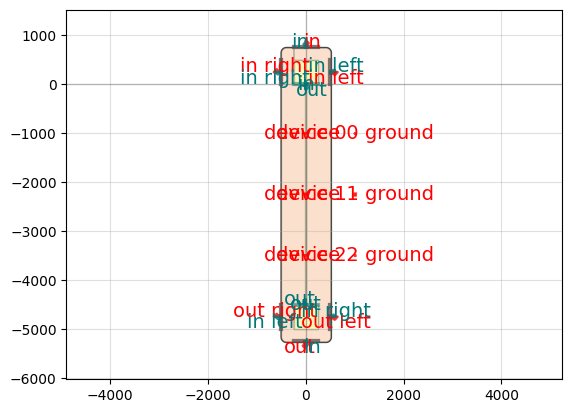

In [34]:
feedline_left = Feedline()

feedline_points = [(0, 0), (4500, 0)]
# device_points = [(1200, 600), (1200, 1000), (1200, 1400), (3300, 1400), (3300, 1000), (3300, 600)]
# ground_points = [(700, 600), (700, 1000), (700, 1400), (3800, 1400), (3800, 1000), (3800, 600)]

# device_points = [(1200, 500), (1200, 1300), (3300, 1300), (3300, 500), (2250, 1500)]
# device_orientations = [0, 180, 0, 180, 90]
# ground_points = [(1705, 500), (695, 1300), (3805, 1300), (2795, 500), (2250, 2005)]

device_points = [(1000, 0), (2250, 0), (3500, 0)]
device_orientations = [90, 90, 90]
ground_points = [(1000, 1005), (2250, 1005), (3500, 1005)]

feedline_params = FeedlineParams(feedline_points=feedline_points, 
                                 device_points=device_points, 
                                 device_ground_points=ground_points,
                                 device_orientations=device_orientations,
                                 ground_avoidance_spacing=10)

feedline_left.generate_feedline(feedline_params)

feedline_left.device.rotate(-90)



qp(feedline_left.device)


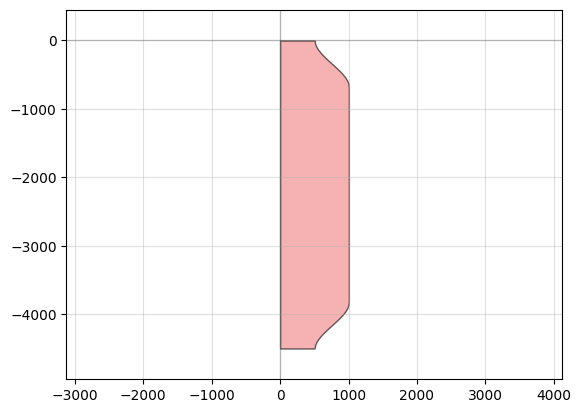

In [35]:
def smooth_step(t):
    """
    Vectorized smooth_step function for input array 't'.
    """
    start_width = 505*2
    taper_length = 0.15 #in percent
    middle_width = 1005*2

    # Convert input to a NumPy array (supports scalar input as well)
    t = np.asarray(t)

    # Create an array to store results
    result = np.full_like(t, middle_width, dtype=np.float64)

    # Calculate smooth transitions for the start taper
    mask_start = t < taper_length
    x_start = t[mask_start] / taper_length
    result[mask_start] = start_width + (3 * x_start**2 - 2 * x_start**3) * (middle_width - start_width)

    # Calculate smooth transitions for the end taper
    mask_end = t > 1 - taper_length
    x_end = (1 - t[mask_end]) / taper_length
    result[mask_end] = start_width + (3 * x_end**2 - 2 * x_end**3) * (middle_width - start_width)

    return result



P = Path()
P.append( pp.straight(length = feedline_points[-1][0] - feedline_points[0][0]) )
    
X = CrossSection()
X.add(width = smooth_step, offset = 0,  layer = default_ls['optical'])


lower_half_plane = Device('lower half plane')
lower_half_plane.add_polygon([(-1e6, -1e6), (1e6, -1e6), (-1e6, 0), (1e6, 0)])
waveguide_device = pg.boolean(A=P.extrude(X), B=lower_half_plane, operation='A-B', layer=default_ls['optical'])


waveguide_device.rotate(-90)


qp(waveguide_device)

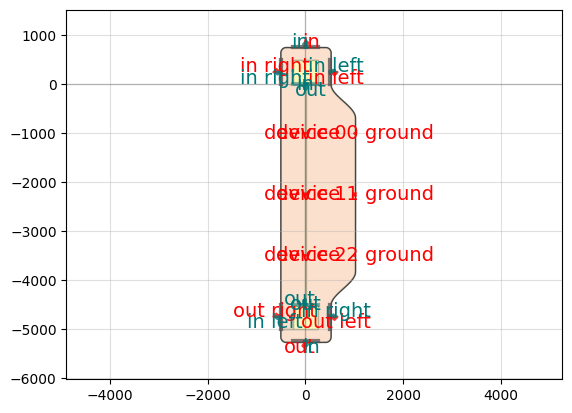

In [36]:
feedline_left.device << waveguide_device

feedline_left.device.remove_layers([default_ls['ground_avoidance']])
feedline_left.device << feedline_left.create_ground_avoidance(feedline_params)

utils.unify_layer(feedline_left.device, default_ls['optical'])
utils.unify_layer(feedline_left.device, default_ls['ground_avoidance'])

qp(feedline_left.device)

In [37]:
Ns = [47, 46, 45]

print(Ns)

spirals: list[Spiral] = []

for N in Ns:
    spiral = Spiral()
    spiral.generate_spiral(SpiralParams(N=N, connector_length=0, n=3500))

    spirals.append(spiral)


print([np.round(spiral.get_resonance_frequency()) for spiral in spirals])
print([np.round(spiral.get_length()) for spiral in spirals])

[47, 46, 45]
[-50688678.0, -1083772.0, 51803297.0]
[43080.0, 41298.0, 39553.0]


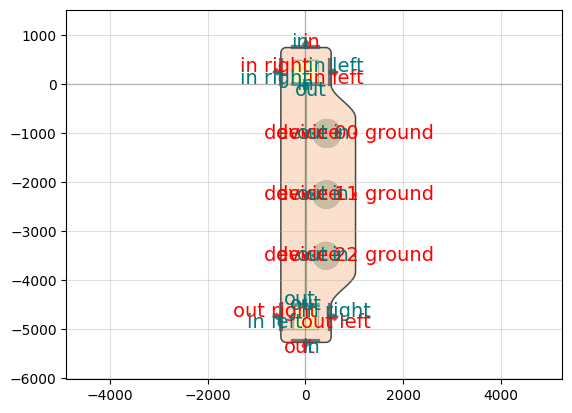

In [38]:
coupling_distance = 150
Resonators: list[DeviceReference] = []

for i,spiral in enumerate(spirals):
    Resonators.append(feedline_left.device << spiral.device)

    Resonators[-1].connect('out', feedline_left.device.ports[f'device {i}'])

    #angle = device_orientations[i]*((2*np.pi)/360)
    #Resonators[-1].move((coupling_distance * np.cos(angle), coupling_distance * np.sin(angle)))
    normal = Resonators[-1].ports['in'].normal[1] - Resonators[-1].ports['in'].normal[0]
    Resonators[-1].move(normal * coupling_distance)


qp(feedline_left.device)

In [39]:

feedline_left.correct_optical_layer()

In [40]:
feedline_left.device.write_gds('Feedline_Left.gds')

with open('feedline_left.pkl', 'wb') as f:
    pickle.dump(feedline_left, f)

In [41]:
capa_spacing = 2
shadow_shift = 0.3

def connect_to_resonator(element: Union[JJResistor, SquidResistor, JJSquidResistor, Squid, JJ],
                         element_port_name: str,
                         resonator: DeviceReference, 
                         capa_distance: float = capa_spacing + shadow_shift) -> None:

    element_port = element.device.ports[element_port_name]

    resonator_normal = resonator.ports['out'].normal[1] - resonator.ports['out'].normal[0]
    element_normal = element_port.normal[1] - element_port.normal[0]

    angle = np.round((360/(2*np.pi)) * np.arccos(np.clip(np.dot(resonator_normal,-element_normal), -1, 1)))%360

    if angle != 0:
        element.device.rotate(-angle)
        element.device.mirror()

    element.device.move(element_port, resonator.ports['out'])
    element.device.move(capa_distance * resonator_normal)

def add_ground_capacitor(element: Union[JJResistor, SquidResistor, JJSquidResistor],
                         element_port_name: str, 
                         feedline: Feedline,
                         device_number: int, 
                         capa_distance: float = capa_spacing + shadow_shift) -> None:

    element_port: Port = element.device.ports[element_port_name]

    distance_to_ground = np.abs(- element_port.y + feedline.device.ports[f'device {device_number} ground'].y) + np.abs(- element_port.x + feedline.device.ports[f'device {device_number} ground'].x) + capa_distance

    ground_capa = GroundCapa()
    ground_capa.generate_ground_capa(GroundCapaParams(distance_to_ground=distance_to_ground, orientation=-90))

    ground_capa_ref = feedline.device << ground_capa.device

    ground_normal = feedline.device.ports[f'device {device_number} ground'].normal[1] - feedline.device.ports[f'device {device_number} ground'].normal[0]
    capa_normal = ground_capa.pad.ports['ground'].normal[1] - ground_capa.pad.ports['ground'].normal[0]
    
    angle = np.round((360/(2*np.pi)) * np.arccos(np.clip(np.dot(ground_normal, capa_normal), -1, 1)))%360

    if angle != 0:
        ground_capa.device.rotate(-angle)

    ground_capa.device.move(ground_capa.plate.ports['capa'], element_port)
    ground_capa.device.move(-capa_distance * ground_normal)

    feedline.device << ground_capa.device

In [42]:

QuantumCircuits: list[DeviceReference] = []

writefield_params = WritefieldParams()
squid_params = SquidParams()







res_params = ResParams(small_resistor=True, connectors=False, num_segments=5, segment_length=25) #10kOhm (removed later on)
capa_params = CapaParams(length_y=20, no_resistor=True)

squid_resistor = SquidResistor()
squid_resistor.generate_squid_resistor(res_params, squid_params, capa_params, writefield_params)
squid_resistor.device.remove(squid_resistor.shunt_resistor)
# squid_resistor.device.mirror()

connect_to_resonator(squid_resistor, 'capa top', Resonators[0])


QuantumCircuits.append(feedline_left.device << squid_resistor.device)

add_ground_capacitor(squid_resistor, 'capa bot', feedline_left, device_number=0)






res_params = ResParams(small_resistor=False, connectors=True, spacing=4, num_segments=10, segment_length=50) #1MOhm
capa_params = CapaParams(length_y=20)

squid_resistor = SquidResistor()
squid_resistor.generate_squid_resistor(res_params, squid_params, capa_params, writefield_params)
squid_resistor.device.mirror(p1=(1,0), p2=(0,0))

connect_to_resonator(squid_resistor, 'capa bot', Resonators[1])


QuantumCircuits.append(feedline_left.device << squid_resistor.device)

add_ground_capacitor(squid_resistor, 'capa top', feedline_left, device_number=1)






res_params = ResParams(small_resistor=True, connectors=False, num_segments=5, segment_length=25) #10kOhm
capa_params = CapaParams(length_y=20)

squid_resistor = SquidResistor()
squid_resistor.generate_squid_resistor(res_params, squid_params, capa_params, writefield_params)
# squid_resistor.device.mirror()

connect_to_resonator(squid_resistor, 'capa top', Resonators[2])


QuantumCircuits.append(feedline_left.device << squid_resistor.device)

add_ground_capacitor(squid_resistor, 'capa bot', feedline_left, device_number=2)





feedline_left.correct_optical_layer()

failed offsetting undercut
